In [ ]:
import os, sys, subprocess, tarfile

# Install dependencies
subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'POT', 'einops', 'pyyaml', 'tqdm', 'matplotlib', 'scipy', '-q'])

# Extract codebase
tar_path = "lmc_vit.tar"
work_dir = "lmc_vit"
if not os.path.exists(work_dir):
    with tarfile.open(tar_path, 'r:*') as tar:
        tar.extractall(path=".")
    print(f"✅ Extracted {tar_path}")
else:
    print(f"✅ {work_dir} already exists")

sys.path.insert(0, work_dir)
print("✅ Setup complete")


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python -m pip install --upgrade pip


✅ lmc_vit already exists
✅ Setup complete


In [ ]:
# ============================================================
# CONFIGURE THESE PATHS to point to your specific files.
# ============================================================
MODEL_A_WEIGHTS = "1cifar10.pth"
MODEL_A_CONFIG = "config1.yaml"

MODEL_B_WEIGHTS = "2cifar10.pth"
MODEL_B_CONFIG = "config2.yaml"

MODEL_C_WEIGHTS = "3cifar10.pth"
MODEL_C_CONFIG = "config3.yaml"
DEVICE = "cuda" if __import__('torch').cuda.is_available() else "cpu"
WM_ITERATIONS = 15
LM_EPOCHS = 15
LM_LR = 1e-3
DIRICHLET_ALPHA = 0.1   # Paper uses alpha=0.1 for 3-way Dirichlet sampling
BATCH_SIZE = 128

print(f"Device: {DEVICE}")

Device: cuda


In [ ]:
import copy, random
import torch
import torch.nn as nn
import torch.optim as optim
import yaml
import numpy as np
from tqdm import tqdm

from lmc_vit.data import get_loaders
from models import build_vit, reparameterize
from weight_matching import weight_matching
from merger import ViTMerger
from barrier import evaluate, summarize

def load_reparam_files(weight_path, config_path, num_classes, device):
    """Load a trained ViT checkpoint from specific file paths."""
    with open(config_path) as f:
        cfg = yaml.safe_load(f)
    m = build_vit(cfg, num_classes).to(device)

    # Load state dict, handling potential nested structures
    sd = torch.load(weight_path, map_location=device, weights_only=False)
    if isinstance(sd, dict) and 'model_state_dict' in sd:
        sd = sd['model_state_dict']
    elif isinstance(sd, dict) and 'state_dict' in sd:
        sd = sd['state_dict']

    m.load_state_dict(sd)
    return reparameterize(m, num_classes).to(device).eval(), cfg

# Load config from first model to get dataset info
with open(MODEL_A_CONFIG) as f:
    cfg = yaml.safe_load(f)
heads = cfg["heads"]
trainloader, testloader, num_classes = get_loaders(cfg["dataset"], batch_size=BATCH_SIZE, root="lmc_vit/data")

# Load all 3 models using the specific file paths
print("Loading Model A...")
model_a, _ = load_reparam_files(MODEL_A_WEIGHTS, MODEL_A_CONFIG, num_classes, DEVICE)

print("Loading Model B...")
model_b, _ = load_reparam_files(MODEL_B_WEIGHTS, MODEL_B_CONFIG, num_classes, DEVICE)

print("Loading Model C...")
model_c, _ = load_reparam_files(MODEL_C_WEIGHTS, MODEL_C_CONFIG, num_classes, DEVICE)

# Verify all 3 work
for name, m in [("A", model_a), ("B", model_b), ("C", model_c)]:
    acc, loss = evaluate(m, testloader, DEVICE)
    print(f"  Model {name}: acc={acc:.2f}%, loss={loss:.4f}")

print("✅ All 3 models loaded and verified")

I0000 00:00:1783872230.544005   25421 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1783872232.719819   25421 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1783872232.721170   25421 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


Loading Model A...
Loading Model B...
Loading Model C...
  Model A: acc=86.32%, loss=0.5124
  Model B: acc=85.93%, loss=0.5258
  Model C: acc=85.52%, loss=0.5467
✅ All 3 models loaded and verified


In [ ]:
# =================================================================
# UNIVERSE MATCHING (Paper Section 4.3)
#
# Algorithm:
#   1. Initialize universe U = model_A (seed model)
#   2. For N iterations:
#      a. Align each model to U via weight matching
#      b. Update U = average of all aligned models
#   3. The final alignment transforms {π_m} bring all models
#      into a shared coordinate system
#
# This is the data-free step before learned refinement.
# =================================================================

N_UNIVERSE_ITERATIONS = 5  # Paper: converges by ~5 iterations (Appendix C.2)

# Work on deep copies so originals stay untouched
models = [copy.deepcopy(model_a), copy.deepcopy(model_b), copy.deepcopy(model_c)]

# Initialize universe as model A (the "seed" model)
universe = copy.deepcopy(models[0])

print("Running Universe Matching...")
for iteration in range(N_UNIVERSE_ITERATIONS):
    aligned_sds = []
    for m_idx in range(len(models)):
        aligned = copy.deepcopy(models[m_idx])
        # Align this model to the current universe
        weight_matching(universe, aligned, heads, iterations=WM_ITERATIONS)
        aligned_sds.append(aligned.state_dict())

    # Update universe = average of all aligned models
    avg_sd = {}
    for key in aligned_sds[0]:
        avg_sd[key] = sum(sd[key] for sd in aligned_sds) / len(aligned_sds)
    universe.load_state_dict(avg_sd)

    print(f"  Universe iteration {iteration+1}/{N_UNIVERSE_ITERATIONS} complete")

# Final alignment: align each model to the converged universe
final_models = []
for m_idx in range(len(models)):
    aligned = copy.deepcopy(models[m_idx])
    weight_matching(universe, aligned, heads, iterations=WM_ITERATIONS)
    final_models.append(aligned)

print("✅ Universe matching complete. All 3 models aligned to shared space.")

Running Universe Matching...


An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


  Universe iteration 1/5 complete
  Universe iteration 2/5 complete
  Universe iteration 3/5 complete
  Universe iteration 4/5 complete
  Universe iteration 5/5 complete
✅ Universe matching complete. All 3 models aligned to shared space.


In [ ]:
from einops import rearrange
from enums import MatrixType
from models import RMSNorm
from utils import project, project_to_attn_circuits

_DIRICHLET_ALPHA = 0.1
_LM_EPOCHS = 30      
_LM_LR = 1e-3

# ---------------- 3-way per-module mergers ---------------- #
class LinearMerger3(nn.Module):
    def __init__(self, l0, l1, l2):
        super().__init__()
        self.register_buffer("w0", l0.weight.data.t().clone().contiguous())
        self.register_buffer("w1", l1.weight.data.t().clone().contiguous())
        self.register_buffer("w2", l2.weight.data.t().clone().contiguous())
        self.has_bias = all(l.bias is not None for l in (l0, l1, l2))
        if self.has_bias:
            self.register_buffer("b0", l0.bias.data.clone())
            self.register_buffer("b1", l1.bias.data.clone())
            self.register_buffer("b2", l2.bias.data.clone())
        self.P_in1 = self.P_out1 = self.P_in2 = self.P_out2 = None
        self.nf = self.w0.shape[1]

    def forward(self, x, coeffs):
        ca, cb, cc = coeffs
        size_out = x.size()[:-1] + (self.nf,)
        w1a = self.P_in1 @ self.w1 @ self.P_out1
        w2a = self.P_in2 @ self.w2 @ self.P_out2
        weight = ca * self.w0 + cb * w1a + cc * w2a
        x = torch.matmul(x.view(-1, x.size(-1)), weight)
        if self.has_bias:
            x = x + ca * self.b0 + cb * (self.b1 @ self.P_out1) + cc * (self.b2 @ self.P_out2)
        return x.view(size_out)

class EmbeddingMerger3(nn.Module):
    def __init__(self, e0, e1, e2):
        super().__init__()
        self.embedding_0 = copy.deepcopy(e0)
        self.embedding_1 = copy.deepcopy(e1)
        self.embedding_2 = copy.deepcopy(e2)
        for p in self.parameters():
            p.requires_grad = False
        self.P1 = self.P2 = None

    def forward(self, x, coeffs):
        ca, cb, cc = coeffs
        return (ca * self.embedding_0(x) + cb * (self.embedding_1(x) @ self.P1)
                + cc * (self.embedding_2(x) @ self.P2))

class RMSMerger3(nn.Module):
    def __init__(self, r0, r1, r2, dim):
        super().__init__()
        self.has_bias = all(r.offset is not None for r in (r0, r1, r2))
        if self.has_bias:
            self.register_buffer("bias_0", r0.offset.data.clone())
            self.register_buffer("bias_1", r1.offset.data.clone())
            self.register_buffer("bias_2", r2.offset.data.clone())
        self.norm = RMSNorm(dim, eps=r0.eps)
        self.P1 = self.P2 = None

    def forward(self, x, coeffs):
        ca, cb, cc = coeffs
        x = self.norm(x)
        if self.has_bias:
            return x + ca * self.bias_0 + cb * (self.bias_1 @ self.P1.t()) + cc * (self.bias_2 @ self.P2.t())
        return x

class LayerNormMerger3(nn.Module):
    def __init__(self, ln0, ln1, ln2):
        super().__init__()
        self.eps = ln0.eps
        for n, m in (("w0", ln0.weight), ("b0", ln0.bias), ("w1", ln1.weight),
                    ("b1", ln1.bias), ("w2", ln2.weight), ("b2", ln2.bias)):
            self.register_buffer(n, m.data.clone())

    def forward(self, x, coeffs):
        ca, cb, cc = coeffs
        xn = (x - x.mean(-1, keepdim=True)) / torch.sqrt(x.var(-1, unbiased=False, keepdim=True) + self.eps)
        w = ca * self.w0 + cb * self.w1 + cc * self.w2
        b = ca * self.b0 + cb * self.b1 + cc * self.b2
        return w * xn + b

class PatchEmbeddingMerger3(nn.Module):
        def __init__(self, pe):
            super().__init__()
            self.patch_embedding = pe

        def __getitem__(self, idx):
            return self.patch_embedding[idx]

        def forward(self, x, coeffs):
            x = self.patch_embedding[0](x)
            x = self.patch_embedding[1](x, coeffs)
            x = self.patch_embedding[2](x, coeffs)
            return self.patch_embedding[3](x)

class FeedForwardMerger3(nn.Module):
        def __init__(self, ff):
            super().__init__()
            self.feedforward = ff

        def __getitem__(self, idx):
            return self.feedforward[idx]

        def forward(self, x, coeffs):
            x = self.feedforward[0](x, coeffs)
            x = self.feedforward[1](x)
            x = self.feedforward[2](x)
            x = self.feedforward[3](x, coeffs)
            return self.feedforward[4](x)

class AttnQKVMerger3(nn.Module):
    def __init__(self, q0, q1, q2, num_heads, embed_dim):
        super().__init__()
        self.register_buffer("w0", q0.weight.data.t().clone().contiguous())
        self.register_buffer("w1", q1.weight.data.t().clone().contiguous())
        self.register_buffer("w2", q2.weight.data.t().clone().contiguous())
        self.num_heads, self.embed_dim = num_heads, embed_dim
        self.nf = self.w0.shape[1]
        self.P_in1 = self.P_out1 = self.P_in2 = self.P_out2 = None

    def _permute(self, weight, P_in, P_out):
        def permute(A, P):
            return torch.matmul(P, A.reshape(A.shape[0], -1)).reshape(A.shape[0], A.shape[1], A.shape[2])
        Q, K, V = weight.t().chunk(3, dim=0)
        Q = Q @ P_in.t()
        Q = rearrange(Q, "(h d) m -> h d m", h=self.num_heads, m=self.embed_dim)
        K = rearrange(K, "(h d) m -> h d m", h=self.num_heads, m=self.embed_dim)
        V = rearrange(V, "(h d) m -> h d m", h=self.num_heads, m=self.embed_dim)
        Q = torch.bmm(Q.transpose(1, 2), P_in.t().expand(self.num_heads, -1, -1)).transpose(1, 2)
        Q, K, V = permute(Q, P_out), permute(K, P_out), permute(V, P_out)
        return torch.cat((Q.reshape(-1, self.embed_dim), K.reshape(-1, self.embed_dim),
                          V.reshape(-1, self.embed_dim)), dim=0).t()

    def forward(self, x, coeffs):
        ca, cb, cc = coeffs
        size_out = x.size()[:-1] + (self.nf,)
        w1a = self._permute(self.w1, self.P_in1, self.P_out1)
        w2a = self._permute(self.w2, self.P_in2, self.P_out2)
        weight = ca * self.w0 + cb * w1a + cc * w2a
        return torch.mm(x.view(-1, x.size(-1)), weight).view(size_out)

class AttnOutMerger3(nn.Module):
    def __init__(self, o0, o1, o2, num_heads, embed_dim):
        super().__init__()
        self.register_buffer("w0", o0.weight.data.t().clone().contiguous())
        self.register_buffer("w1", o1.weight.data.t().clone().contiguous())
        self.register_buffer("w2", o2.weight.data.t().clone().contiguous())
        self.has_bias = all(o.bias is not None for o in (o0, o1, o2))
        if self.has_bias:
            self.register_buffer("b0", o0.bias.data.clone())
            self.register_buffer("b1", o1.bias.data.clone())
            self.register_buffer("b2", o2.bias.data.clone())
        self.num_heads, self.embed_dim = num_heads, embed_dim
        self.nf = self.w0.shape[1]
        self.P_in1 = self.P_out1 = self.P_in2 = self.P_out2 = None

    def _permute(self, weight, P_out_res, P_head):
        def permute(A, P):
            return torch.matmul(P, A.reshape(A.shape[0], -1)).reshape(A.shape[0], A.shape[1], A.shape[2])
        OUT = rearrange(weight.t(), "m (h d) -> m h d", h=self.num_heads, m=self.embed_dim).permute(1, 2, 0)
        OUT = (OUT.transpose(1, 2) @ P_out_res.expand(self.num_heads, -1, -1)).transpose(1, 2)
        OUT = permute(OUT, P_head)
        return OUT.permute(2, 0, 1).reshape(self.embed_dim, -1).t()

    def forward(self, x, coeffs):
        ca, cb, cc = coeffs
        size_out = x.size()[:-1] + (self.nf,)
        w1a = self._permute(self.w1 @ self.P_out1, self.P_out1, self.P_in1)
        w2a = self._permute(self.w2 @ self.P_out2, self.P_out2, self.P_in2)
        weight = ca * self.w0 + cb * w1a + cc * w2a
        x = torch.mm(x.view(-1, x.size(-1)), weight)
        if self.has_bias:
            x = x + ca * self.b0 + cb * (self.b1 @ self.P_out1) + cc * (self.b2 @ self.P_out2)
        return x.view(size_out)

class TripleViTMerger(nn.Module):
    def __init__(self, model_a, model_b, model_c, num_heads, device="cpu"):
        super().__init__()
        model_a, model_b, model_c = model_a.eval(), model_b.eval(), model_c.eval()
        embed_dim = model_a.pos_embedding.weight.shape[1]
        patch_dim = model_a.to_patch_embedding[2].weight.shape[1]
        n_layers = len(model_a.transformer.layers)

        for i in range(n_layers):
            project_to_attn_circuits(model_a, num_heads, embed_dim, i)
            project_to_attn_circuits(model_b, num_heads, embed_dim, i)
            project_to_attn_circuits(model_c, num_heads, embed_dim, i)

        self.proj = nn.ParameterDict({
            "residual_b": nn.Parameter(torch.eye(embed_dim)),
            "residual_c": nn.Parameter(torch.eye(embed_dim)),
        })
        for i in range(n_layers):
            self.proj[f"heads_{i}_b"] = nn.Parameter(torch.eye(num_heads))
            self.proj[f"heads_{i}_c"] = nn.Parameter(torch.eye(num_heads))
            mlp_dim = model_a.transformer.layers[i][3].net[0].weight.shape[0]
            self.proj[f"mlp_{i}_b"] = nn.Parameter(torch.eye(mlp_dim))
            self.proj[f"mlp_{i}_c"] = nn.Parameter(torch.eye(mlp_dim))

        self.model = copy.deepcopy(model_a)
        self.model.pos_embedding = EmbeddingMerger3(model_a.pos_embedding, model_b.pos_embedding, model_c.pos_embedding)
        self.model.to_patch_embedding[2] = LinearMerger3(model_a.to_patch_embedding[2], model_b.to_patch_embedding[2], model_c.to_patch_embedding[2])
        self.model.to_patch_embedding[2].P_in1 = torch.eye(patch_dim, device=device)
        self.model.to_patch_embedding[2].P_in2 = torch.eye(patch_dim, device=device)
        self.model.to_patch_embedding[1] = LayerNormMerger3(model_a.to_patch_embedding[1], model_b.to_patch_embedding[1], model_c.to_patch_embedding[1])
        self.model.to_patch_embedding = PatchEmbeddingMerger3(self.model.to_patch_embedding)

        for i in range(n_layers):
            layer = self.model.transformer.layers[i]
            layer[3].net[0] = LinearMerger3(model_a.transformer.layers[i][3].net[0], model_b.transformer.layers[i][3].net[0], model_c.transformer.layers[i][3].net[0])
            layer[3].net[3] = LinearMerger3(model_a.transformer.layers[i][3].net[3], model_b.transformer.layers[i][3].net[3], model_c.transformer.layers[i][3].net[3])
            layer[1].to_qkv = AttnQKVMerger3(model_a.transformer.layers[i][1].to_qkv, model_b.transformer.layers[i][1].to_qkv, model_c.transformer.layers[i][1].to_qkv, num_heads, embed_dim)
            layer[1].to_out[0] = AttnOutMerger3(model_a.transformer.layers[i][1].to_out[0], model_b.transformer.layers[i][1].to_out[0], model_c.transformer.layers[i][1].to_out[0], num_heads, embed_dim)
            layer[0] = RMSMerger3(model_a.transformer.layers[i][0], model_b.transformer.layers[i][0], model_c.transformer.layers[i][0], embed_dim)
            layer[2] = RMSMerger3(model_a.transformer.layers[i][2], model_b.transformer.layers[i][2], model_c.transformer.layers[i][2], embed_dim)
            layer[3].net = FeedForwardMerger3(layer[3].net)

        self.model.final_norm = RMSMerger3(model_a.final_norm, model_b.final_norm, model_c.final_norm, embed_dim)
        self.model.linear_head = LinearMerger3(model_a.linear_head, model_b.linear_head, model_c.linear_head)
        self.model.linear_head.P_out1 = torch.eye(model_a.linear_head.weight.shape[0], device=device)
        self.model.linear_head.P_out2 = torch.eye(model_a.linear_head.weight.shape[0], device=device)

    def _project(self):
        Qb, _ = torch.linalg.qr(self.proj["residual_b"]); Pb, Pbt = Qb, Qb.t()
        Qc, _ = torch.linalg.qr(self.proj["residual_c"]); Pc, Pct = Qc, Qc.t()
        self.model.pos_embedding.P1, self.model.pos_embedding.P2 = Pb, Pc
        self.model.to_patch_embedding[2].P_out1 = Pb
        self.model.to_patch_embedding[2].P_out2 = Pc
        for i in range(len(self.model.transformer.layers)):
            layer = self.model.transformer.layers[i]
            P_mlp_b = project(self.proj[f"mlp_{i}_b"], MatrixType.PERM)
            P_mlp_c = project(self.proj[f"mlp_{i}_c"], MatrixType.PERM)
            layer[3].net[0].P_in1, layer[3].net[0].P_in2 = Pbt, Pct
            layer[3].net[0].P_out1, layer[3].net[0].P_out2 = P_mlp_b, P_mlp_c
            layer[3].net[3].P_in1, layer[3].net[3].P_in2 = P_mlp_b.t(), P_mlp_c.t()
            layer[3].net[3].P_out1, layer[3].net[3].P_out2 = Pb, Pc
            P_heads_b = project(self.proj[f"heads_{i}_b"], MatrixType.PERM)
            P_heads_c = project(self.proj[f"heads_{i}_c"], MatrixType.PERM)
            layer[1].to_qkv.P_in1, layer[1].to_qkv.P_in2 = Pbt, Pct
            layer[1].to_qkv.P_out1, layer[1].to_qkv.P_out2 = P_heads_b, P_heads_c
            layer[1].to_out[0].P_in1, layer[1].to_out[0].P_in2 = P_heads_b, P_heads_c
            layer[1].to_out[0].P_out1, layer[1].to_out[0].P_out2 = Pb, Pc
            layer[0].P1, layer[0].P2 = Pbt, Pct
            layer[2].P1, layer[2].P2 = Pbt, Pct
        self.model.final_norm.P1, self.model.final_norm.P2 = Pbt, Pct
        self.model.linear_head.P_in1, self.model.linear_head.P_in2 = Pbt, Pct

    def forward(self, img, coeffs):
        self._project()
        return self.model(img, coeff=coeffs)

triple_merger = TripleViTMerger(
    copy.deepcopy(final_models[0]), copy.deepcopy(final_models[1]), copy.deepcopy(final_models[2]),
    num_heads=heads, device=DEVICE,
).to(DEVICE)

_trainable_params = [p for p in triple_merger.parameters() if p.requires_grad]
_optimizer = optim.Adam(_trainable_params, lr=_LM_LR)
_criterion = nn.CrossEntropyLoss()

_dirichlet_dist = torch.distributions.Dirichlet(torch.tensor([_DIRICHLET_ALPHA] * 3))
_dirichlet_dist_flat = torch.distributions.Dirichlet(torch.tensor([1.0, 1.0, 1.0]))

_trainloader, _testloader, _num_classes = get_loaders(cfg["dataset"], batch_size=BATCH_SIZE, root="lmc_vit/data", num_workers=0)

print(f"Trainable parameters: {sum(p.numel() for p in _trainable_params)}")
print(f"Training TRUE 3-way learned matching for {_LM_EPOCHS} epochs "
      f"(lambda ~ Dirichlet({_DIRICHLET_ALPHA}) + Dirichlet(1.0) over the full simplex)...")

for _epoch in range(_LM_EPOCHS):
    triple_merger.train()
    _epoch_loss, _n_batches = 0.0, 0
    for _x, _y in tqdm(_trainloader, desc=f"3-way LM ep{_epoch+1}/{_LM_EPOCHS}", leave=False):
        _x, _y = _x.to(DEVICE), _y.to(DEVICE)
        _optimizer.zero_grad()

        if _n_batches % 2 == 0:
            _lam = _dirichlet_dist.sample().to(DEVICE)
        else:
            _lam = _dirichlet_dist_flat.sample().to(DEVICE)

        _logits, _ = triple_merger(_x, coeffs=(_lam[0], _lam[1], _lam[2]))
        _loss = _criterion(_logits, _y)
        _loss.backward()
        _optimizer.step()
        _epoch_loss += _loss.item()
        _n_batches += 1

    triple_merger.eval()
    with torch.no_grad():
        _center_loss, _center_n = 0.0, 0
        for _bi, (_x, _y) in enumerate(_testloader):
            if _bi >= 20:
                break
            _x, _y = _x.to(DEVICE), _y.to(DEVICE)
            _third = torch.tensor(1.0 / 3, device=DEVICE)
            _logits, _ = triple_merger(_x, coeffs=(_third, _third, _third))
            _center_loss += _criterion(_logits, _y).item() * _x.size(0)
            _center_n += _x.size(0)
    print(f"  Epoch {_epoch+1}/{_LM_EPOCHS}: train_loss={_epoch_loss/_n_batches:.4f}  "
          f"center(1/3,1/3,1/3)_test_loss={_center_loss/_center_n:.4f}")

print("✅ True 3-way learned matching complete (full-simplex Dirichlet training)")

Trainable parameters: 3277568
Training TRUE 3-way learned matching for 30 epochs (lambda ~ Dirichlet(0.1) + Dirichlet(1.0) over the full simplex)...


  Epoch 1/30: train_loss=0.7633  center(1/3,1/3,1/3)_test_loss=1.7227


  Epoch 2/30: train_loss=0.5395  center(1/3,1/3,1/3)_test_loss=1.0567


  Epoch 3/30: train_loss=0.4977  center(1/3,1/3,1/3)_test_loss=1.0235


  Epoch 4/30: train_loss=0.4225  center(1/3,1/3,1/3)_test_loss=0.8663


...

  Epoch 26/30: train_loss=0.3201  center(1/3,1/3,1/3)_test_loss=0.8621


  Epoch 27/30: train_loss=0.3234  center(1/3,1/3,1/3)_test_loss=0.7647


  Epoch 28/30: train_loss=0.3212  center(1/3,1/3,1/3)_test_loss=0.8191


  Epoch 29/30: train_loss=0.3274  center(1/3,1/3,1/3)_test_loss=0.7573


  Epoch 30/30: train_loss=0.3367  center(1/3,1/3,1/3)_test_loss=0.7361
✅ True 3-way learned matching complete (full-simplex Dirichlet training)


In [ ]:
print("Saving models to disk...")
torch.save(final_models[0].state_dict(), "final_model_0.pth")
torch.save(final_models[1].state_dict(), "final_model_1.pth")
torch.save(final_models[2].state_dict(), "final_model_2.pth")
torch.save(triple_merger.state_dict(), "triple_merger.pth")
print("✅ Saved! You are now protected against Marimo crashes.")

Saving models to disk...
✅ Saved! You are now protected against Marimo crashes.


Computing endpoint losses...
  Vanilla endpoints: [0.540987471739451, 0.505995492140452, 0.636020282904307]
  WM endpoints:      [0.5420260727405548, 0.5065509875615438, 0.6373264392217001]
  LM endpoints:      [0.542026142279307, 0.5065512557824453, 0.637326717376709]
Evaluating 25x25 = 625 grid points x 3 methods...
  50/625 points evaluated...
  100/625 points evaluated...
  150/625 points evaluated...
  200/625 points evaluated...
  250/625 points evaluated...
  300/625 points evaluated...
  350/625 points evaluated...
  400/625 points evaluated...
  450/625 points evaluated...
  500/625 points evaluated...
  550/625 points evaluated...
  600/625 points evaluated...
✅ Evaluation complete! Drawing...

  NUMERICAL BARRIER RESULTS (sup over full simplex grid)
  Vanilla averaging  : Barrier = 3.8937
  Weight matching    : Barrier = 5.6853
  Learned matching   : Barrier = 2.4136



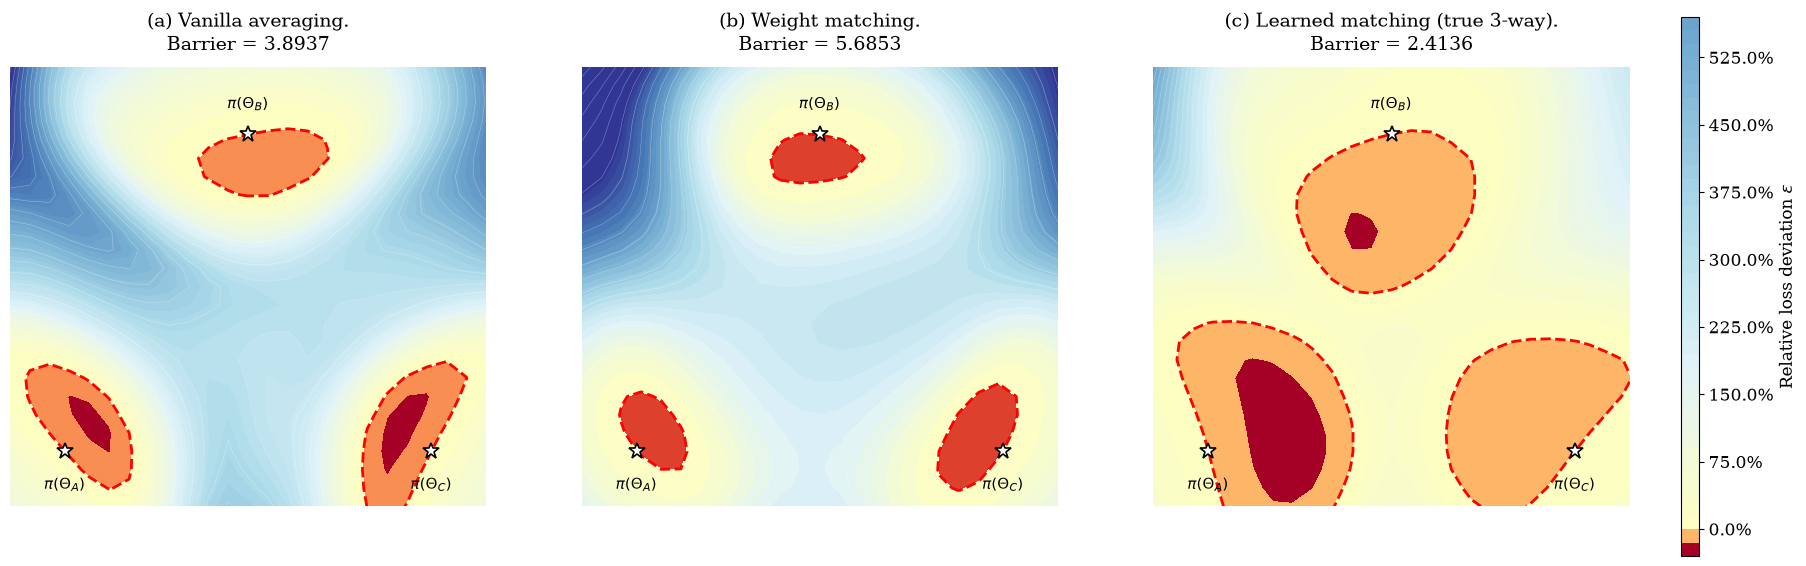

In [ ]:
triple_merger.eval()

# =================================================================
# FIGURE 4 REPLICA — RELATIVE LOSS DEVIATION (epsilon) FROM BASELINE
# LM points are now real forward passes through the jointly-trained
# TripleViTMerger, evaluated at each (lambda_a, lambda_b, lambda_c) --
# no state-dict reconstruction, so no risk of the corridor/interior
# inconsistency from before.
# =================================================================
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
import matplotlib.ticker as mticker

plt.rcParams.update({'font.family': 'serif', 'font.size': 12})
criterion = nn.CrossEntropyLoss()

def interp_state_dict(sds, la, lb, lc):
    return {k: la * sds[0][k] + lb * sds[1][k] + lc * sds[2][k] for k in sds[0]}

@torch.no_grad()
def eval_point_sd(eval_model, sds, la, lb, lc, loader, max_batches=3):
    eval_model.load_state_dict(interp_state_dict(sds, la, lb, lc))
    eval_model.eval()
    total_loss, total_n = 0.0, 0
    for bi, (bx, by) in enumerate(loader):
        if bi >= max_batches:
            break
        bx, by = bx.to(DEVICE), by.to(DEVICE)
        logits, _ = eval_model(bx)
        total_loss += criterion(logits, by).item() * bx.size(0)
        total_n += bx.size(0)
    return total_loss / total_n

@torch.no_grad()
def eval_point_triple(merger, la, lb, lc, loader, max_batches=3):
    merger.eval()
    la_t = torch.tensor(float(la), device=DEVICE)
    lb_t = torch.tensor(float(lb), device=DEVICE)
    lc_t = torch.tensor(float(lc), device=DEVICE)
    total_loss, total_n = 0.0, 0
    for bi, (bx, by) in enumerate(loader):
        if bi >= max_batches:
            break
        bx, by = bx.to(DEVICE), by.to(DEVICE)
        logits, _ = merger(bx, coeffs=(la_t, lb_t, lc_t))
        total_loss += criterion(logits, by).item() * bx.size(0)
        total_n += bx.size(0)
    return total_loss / total_n

_, sq_testloader, _ = get_loaders(cfg["dataset"], batch_size=BATCH_SIZE, root="lmc_vit/data", num_workers=0)

sd_vanilla = [model_a.state_dict(), model_b.state_dict(), model_c.state_dict()]
sd_wm = [final_models[0].state_dict(), final_models[1].state_dict(), final_models[2].state_dict()]

import copy as _copy
eval_vanilla = _copy.deepcopy(model_a).to(DEVICE)
eval_matched = _copy.deepcopy(final_models[0]).to(DEVICE)

# ---- endpoint losses ----
print("Computing endpoint losses...")
ep_van = [eval_point_sd(eval_vanilla, sd_vanilla, 1, 0, 0, sq_testloader),
          eval_point_sd(eval_vanilla, sd_vanilla, 0, 1, 0, sq_testloader),
          eval_point_sd(eval_vanilla, sd_vanilla, 0, 0, 1, sq_testloader)]
ep_wm = [eval_point_sd(eval_matched, sd_wm, 1, 0, 0, sq_testloader),
         eval_point_sd(eval_matched, sd_wm, 0, 1, 0, sq_testloader),
         eval_point_sd(eval_matched, sd_wm, 0, 0, 1, sq_testloader)]
ep_lm = [eval_point_triple(triple_merger, 1, 0, 0, sq_testloader),
         eval_point_triple(triple_merger, 0, 1, 0, sq_testloader),
         eval_point_triple(triple_merger, 0, 0, 1, sq_testloader)]

print(f"  Vanilla endpoints: {ep_van}")
print(f"  WM endpoints:      {ep_wm}")
print(f"  LM endpoints:      {ep_lm}")

# ---- grid over the simplex ----
GRID_STEPS = 25
x_vals = np.linspace(-0.15, 1.15, GRID_STEPS)
y_vals = np.linspace(-0.15, 1.05, GRID_STEPS)
X, Y = np.meshgrid(x_vals, y_vals)

lam_b_grid = Y * (2 / np.sqrt(3))
lam_c_grid = X - Y / np.sqrt(3)
lam_a_grid = 1.0 - X - Y / np.sqrt(3)

losses_vanilla = np.zeros_like(X)
losses_wm = np.zeros_like(X)
losses_lm = np.zeros_like(X)

print(f"Evaluating {GRID_STEPS}x{GRID_STEPS} = {GRID_STEPS**2} grid points x 3 methods...")
total_pts, pts_done = GRID_STEPS * GRID_STEPS, 0
for i in range(GRID_STEPS):
    for j in range(GRID_STEPS):
        la, lb, lc = lam_a_grid[i, j], lam_b_grid[i, j], lam_c_grid[i, j]
        losses_vanilla[i, j] = eval_point_sd(eval_vanilla, sd_vanilla, la, lb, lc, sq_testloader)
        losses_wm[i, j] = eval_point_sd(eval_matched, sd_wm, la, lb, lc, sq_testloader)
        losses_lm[i, j] = eval_point_triple(triple_merger, la, lb, lc, sq_testloader)
        pts_done += 1
        if pts_done % 50 == 0:
            print(f"  {pts_done}/{total_pts} points evaluated...")

print("✅ Evaluation complete! Drawing...")

# ---- correct barrier: sup over the FULL grid of (loss - linear baseline),
#      matching paper Eq. 2 / barrier.py::summarize -- not just 3 edge midpoints ----
def full_grid_barrier(raw_losses, ep):
    baseline = lam_a_grid * ep[0] + lam_b_grid * ep[1] + lam_c_grid * ep[2]
    return float(np.max(raw_losses - baseline))

barrier_van = full_grid_barrier(losses_vanilla, ep_van)
barrier_wm = full_grid_barrier(losses_wm, ep_wm)
barrier_lm = full_grid_barrier(losses_lm, ep_lm)

print(f"\n{'='*50}\n  NUMERICAL BARRIER RESULTS (sup over full simplex grid)\n{'='*50}")
print(f"  Vanilla averaging  : Barrier = {barrier_van:.4f}")
print(f"  Weight matching    : Barrier = {barrier_wm:.4f}")
print(f"  Learned matching   : Barrier = {barrier_lm:.4f}\n{'='*50}\n")

def compute_epsilon(raw_losses, ep):
    baseline = lam_a_grid * ep[0] + lam_b_grid * ep[1] + lam_c_grid * ep[2]
    eps = np.zeros_like(raw_losses)
    mask = baseline > 1e-8
    eps[mask] = (raw_losses[mask] - baseline[mask]) / baseline[mask] * 100.0
    return eps

eps_vanilla = compute_epsilon(losses_vanilla, ep_van)
eps_wm = compute_epsilon(losses_wm, ep_wm)
eps_lm = compute_epsilon(losses_lm, ep_lm)

all_eps = np.concatenate([eps_vanilla.ravel(), eps_wm.ravel(), eps_lm.ravel()])
vmin = min(np.percentile(all_eps, 1), -20)
vmax = max(np.percentile(all_eps, 99), 50)
norm = TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax)

fig, axes = plt.subplots(1, 3, figsize=(22, 7))
titles = [
    f"(a) Vanilla averaging.\nBarrier = {barrier_van:.4f}",
    f"(b) Weight matching.\nBarrier = {barrier_wm:.4f}",
    f"(c) Learned matching (true 3-way).\nBarrier = {barrier_lm:.4f}",
]
datasets = [eps_vanilla, eps_wm, eps_lm]

cf = None
for ax, title, Z in zip(axes, titles, datasets):
    cf = ax.contourf(X, Y, Z, levels=50, cmap='RdYlBu', norm=norm)
    ax.contour(X, Y, Z, levels=20, colors='white', linewidths=0.3, alpha=0.5)
    ax.contour(X, Y, Z, levels=[0], colors='red', linewidths=2.0, linestyles='dashed')
    ax.plot([0], [0], '*', markersize=12, markerfacecolor='white', markeredgecolor='black', markeredgewidth=1.2)
    ax.plot([0.5], [np.sqrt(3)/2], '*', markersize=12, markerfacecolor='white', markeredgecolor='black', markeredgewidth=1.2)
    ax.plot([1], [0], '*', markersize=12, markerfacecolor='white', markeredgecolor='black', markeredgewidth=1.2)
    ax.text(0, -0.07, r'$\pi(\Theta_A)$', ha='center', va='top', fontsize=11)
    ax.text(0.5, np.sqrt(3)/2 + 0.06, r'$\pi(\Theta_B)$', ha='center', va='bottom', fontsize=11)
    ax.text(1, -0.07, r'$\pi(\Theta_C)$', ha='center', va='top', fontsize=11)
    ax.set_title(title, fontsize=14, pad=12)
    ax.set_xlim(-0.15, 1.15)
    ax.set_ylim(-0.15, 1.05)
    ax.set_aspect('equal')
    ax.axis('off')

cbar = fig.colorbar(cf, ax=axes.ravel().tolist(), fraction=0.02, pad=0.03, aspect=30)
cbar.ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.1f}%'))
cbar.set_label(r'Relative loss deviation $\varepsilon$', fontsize=12)

plt.savefig("paper_figure_4_final.png", dpi=300, bbox_inches='tight')
plt.show()